# 01 — Professional Sales & Revenue Analytics
### Dynamic Pricing & Revenue Intelligence System | Final Year B.Tech Project
---
**Objective:** Comprehensive business intelligence, exploratory data analysis, and pricing structure validation.
This notebook analyzes revenue performance, customer demand dynamics, product-store hierarchies, and historical price variations relative to competitors.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Add project root to path
sys.path.append(os.path.abspath("."))
from src.data_loader import load_data, validate_data_quality, clean_data

# Styling settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
sns.set_palette("crest")


## 1. Data Quality & Suitability Audit
Before any analysis, we inspect data integrity, schema types, missingness, duplicates, and check if empirical price-demand variation supports dynamic pricing.


In [2]:
# Load data
df_raw = load_data("data/dataset.csv")
audit = validate_data_quality(df_raw)

print("=== DATA QUALITY & DYNAMIC PRICING SUITABILITY AUDIT ===")
for k, v in audit.items():
    if k != "missing_values":
        print(f" - {k.replace('_', ' ').title()}: {v}")

print("\nMissing Values Summary:")
print(pd.Series(audit["missing_values"]))


=== DATA QUALITY & DYNAMIC PRICING SUITABILITY AUDIT ===
 - Total Records: 58480
 - Columns Count: 22
 - Columns: ['Date', 'Product_ID', 'Product_Name', 'Category', 'Store_ID', 'Store_Name', 'Region', 'Base_Price', 'Our_Price', 'Competitor_Price', 'Discount_Percent', 'Promotion_Flag', 'Unit_Cost', 'Inventory_Level', 'Units_Sold', 'Revenue', 'Total_Cost', 'Gross_Profit', 'Gross_Margin_Percent', 'Price_Difference', 'Price_Ratio', 'Price_Premium_Percent']
 - Duplicate Rows: 0
 - Date Min: 2024-01-01
 - Date Max: 2025-12-31
 - Total Days: 731
 - Unique Products: 20
 - Unique Stores: 4
 - Unique Categories: 5
 - Unique Regions: 4
 - Observations Per Product Store: 731
 - Price Min: 285.0
 - Price Max: 4499.0
 - Price Mean: 1622.3230133378931
 - Competitor Price Available: True
 - Cost Available: True
 - Discount Available: True
 - Promo Available: True
 - Mean Price Demand Correlation: -0.5620981866024981
 - Is Suitable For Dynamic Pricing: True

Missing Values Summary:
Date                

In [3]:
# Clean dataset and prepare analytical table
df = clean_data(df_raw)
df['Month_Year'] = df['Date'].dt.to_period('M')
df['Year'] = df['Date'].dt.year
print(f"Analytical Dataset Ready: {df.shape[0]:,} rows across {df.shape[1]} columns.")
df.head(5)


Analytical Dataset Ready: 58,480 rows across 24 columns.


,Date,Product_ID,Product_Name,Category,Store_ID,Store_Name,Region,Base_Price,Our_Price,Competitor_Price,...,Units_Sold,Revenue,Total_Cost,Gross_Profit,Gross_Margin_Percent,Price_Difference,Price_Ratio,Price_Premium_Percent,Month_Year,Year
0,2024-01-01,PROD_01,Wireless Noise-Canceling Headphones,Electronics,STORE_01,Delhi Flagship Metro,North,2999.0,2999.0,3103.54,...,57,170943.0,100245.33,70697.67,41.357452,-104.54,0.9663,-3.37,2024-01,2024
1,2024-01-02,PROD_01,Wireless Noise-Canceling Headphones,Electronics,STORE_01,Delhi Flagship Metro,North,2999.0,2999.0,3326.22,...,67,200933.0,117168.93,83764.07,41.687563,-327.22,0.9016,-9.84,2024-01,2024
2,2024-01-03,PROD_01,Wireless Noise-Canceling Headphones,Electronics,STORE_01,Delhi Flagship Metro,North,2999.0,2999.0,3228.40,...,52,155948.0,91714.48,64233.52,41.189063,-229.40,0.9289,-7.11,2024-01,2024
3,2024-01-04,PROD_01,Wireless Noise-Canceling Headphones,Electronics,STORE_01,Delhi Flagship Metro,North,2999.0,2999.0,3137.97,...,46,137954.0,81892.42,56061.58,40.637879,-138.97,0.9557,-4.43,2024-01,2024
4,2024-01-05,PROD_01,Wireless Noise-Canceling Headphones,Electronics,STORE_01,Delhi Flagship Metro,North,2999.0,2999.0,3210.99,...,57,170943.0,99791.04,71151.96,41.623208,-211.99,0.9340,-6.60,2024-01,2024


## 2. Executive Business KPIs
Key commercial health indicators across revenue, volume, average pricing, profit margins, and competitive stance.


In [4]:
total_revenue = df['Revenue'].sum()
total_units = df['Units_Sold'].sum()
total_profit = df['Gross_Profit'].sum()
avg_asp = df['Revenue'].sum() / df['Units_Sold'].sum()
avg_cost = df['Total_Cost'].sum() / df['Units_Sold'].sum()
overall_margin_pct = (total_profit / total_revenue) * 100.0
avg_discount = df['Discount_Percent'].mean()
avg_comp_price = df['Competitor_Price'].mean()
avg_our_price = df['Our_Price'].mean()
avg_price_gap = ((avg_our_price - avg_comp_price) / avg_comp_price) * 100.0

kpi_data = [
    ["Total Gross Revenue", f"INR {total_revenue:,.2f}"],
    ["Total Units Sold", f"{total_units:,} units"],
    ["Total Gross Profit", f"INR {total_profit:,.2f}"],
    ["Overall Gross Margin", f"{overall_margin_pct:.2f}%"],
    ["Average Selling Price (ASP)", f"INR {avg_asp:.2f}"],
    ["Average Unit Cost", f"INR {avg_cost:.2f}"],
    ["Average Promotional Discount", f"{avg_discount:.2f}%"],
    ["Average Competitor Price", f"INR {avg_comp_price:.2f}"],
    ["Average Price Gap vs Competitor", f"{avg_price_gap:+.2f}%"]
]

print(tabulate(kpi_data, headers=["Executive Metric", "Calculated Value"], tablefmt="fancy_grid"))


╒═════════════════════════════════╤══════════════════════╕
│ Executive Metric                │ Calculated Value     │
╞═════════════════════════════════╪══════════════════════╡
│ Total Gross Revenue             │ INR 6,177,366,601.98 │
├─────────────────────────────────┼──────────────────────┤
│ Total Units Sold                │ 5,165,558 units      │
├─────────────────────────────────┼──────────────────────┤
│ Total Gross Profit              │ INR 2,469,144,356.94 │
├─────────────────────────────────┼──────────────────────┤
│ Overall Gross Margin            │ 39.97%               │
├─────────────────────────────────┼──────────────────────┤
│ Average Selling Price (ASP)     │ INR 1195.88          │
├─────────────────────────────────┼──────────────────────┤
│ Average Unit Cost               │ INR 717.87           │
├─────────────────────────────────┼──────────────────────┤
│ Average Promotional Discount    │ 2.07%                │
├─────────────────────────────────┼─────────────────────

## 3. Sales Trend & Seasonality Analysis
Tracking daily, weekly, and monthly commercial performance alongside rolling 30-day averages and MoM growth trajectories.


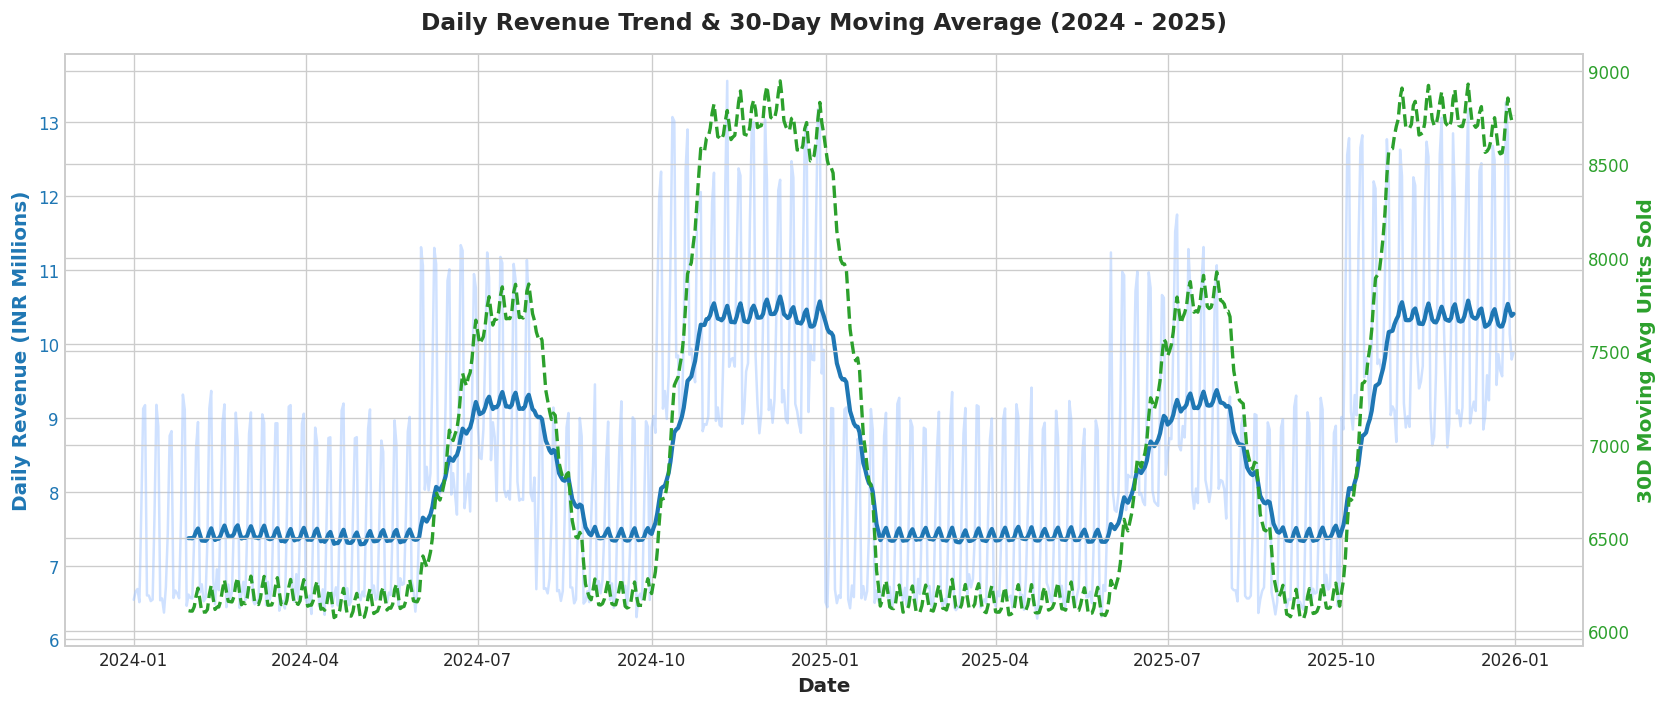

In [5]:
# Daily and 30-day rolling revenue
daily_trend = df.groupby('Date').agg({
    'Revenue': 'sum',
    'Units_Sold': 'sum',
    'Gross_Profit': 'sum'
}).reset_index()

daily_trend['Revenue_30D_MA'] = daily_trend['Revenue'].rolling(window=30).mean()
daily_trend['Units_30D_MA'] = daily_trend['Units_Sold'].rolling(window=30).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))

color = '#1f77b4'
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Daily Revenue (INR Millions)', color=color, fontsize=12, fontweight='bold')
ax1.plot(daily_trend['Date'], daily_trend['Revenue'] / 1e6, color='#a0c4ff', alpha=0.5, label='Daily Revenue')
ax1.plot(daily_trend['Date'], daily_trend['Revenue_30D_MA'] / 1e6, color=color, linewidth=2.5, label='30-Day Moving Average')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#2ca02c'
ax2.set_ylabel('30D Moving Avg Units Sold', color=color, fontsize=12, fontweight='bold')
ax2.plot(daily_trend['Date'], daily_trend['Units_30D_MA'], color=color, linestyle='--', linewidth=2, label='30-Day MA Units')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Daily Revenue Trend & 30-Day Moving Average (2024 - 2025)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()


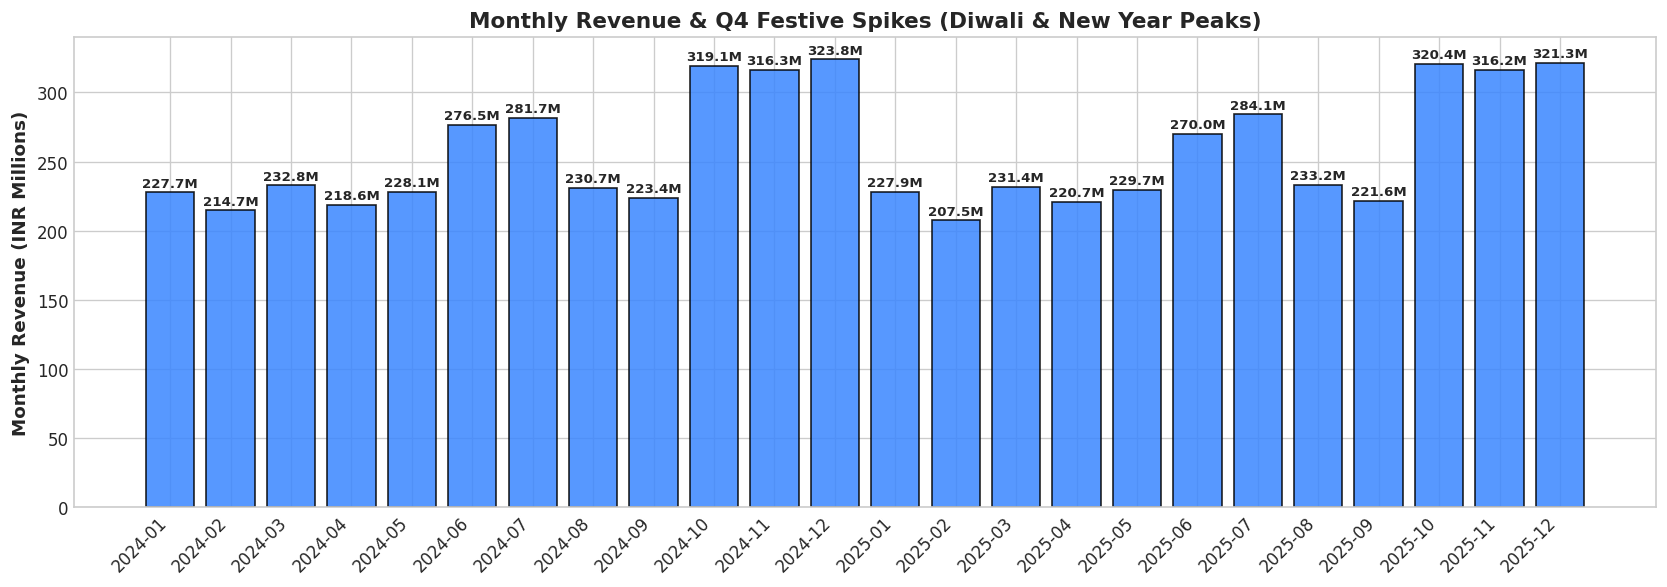

In [6]:
# Monthly Revenue & MoM Growth %
monthly_trend = df.groupby('Month_Year').agg({
    'Revenue': 'sum',
    'Units_Sold': 'sum',
    'Gross_Profit': 'sum'
}).reset_index()

monthly_trend['Month_Str'] = monthly_trend['Month_Year'].astype(str)
monthly_trend['MoM_Revenue_Growth_%'] = monthly_trend['Revenue'].pct_change() * 100.0

plt.figure(figsize=(14, 5))
bars = plt.bar(monthly_trend['Month_Str'], monthly_trend['Revenue'] / 1e6, color='#3a86ff', alpha=0.85, edgecolor='black', label='Revenue (M INR)')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylabel('Monthly Revenue (INR Millions)', fontsize=11, fontweight='bold')
plt.title('Monthly Revenue & Q4 Festive Spikes (Diwali & New Year Peaks)', fontsize=13, fontweight='bold')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{yval:.1f}M", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Product Performance & Value Matrix
Analyzing top and bottom products, sales velocity, margin contributions, and volume vs revenue distribution.


In [7]:
prod_summary = df.groupby(['Product_ID', 'Product_Name', 'Category']).agg({
    'Revenue': 'sum',
    'Units_Sold': 'sum',
    'Gross_Profit': 'sum',
    'Our_Price': 'mean',
    'Gross_Margin_Percent': 'mean'
}).reset_index().sort_values(by='Revenue', ascending=False)

prod_summary['Revenue_Share_%'] = (prod_summary['Revenue'] / total_revenue) * 100.0
prod_summary['Cumulative_Share_%'] = prod_summary['Revenue_Share_%'].cumsum()

print("Top 5 Products by Revenue:")
print(tabulate(
    prod_summary[['Product_ID', 'Product_Name', 'Category', 'Revenue', 'Revenue_Share_%', 'Gross_Margin_Percent']].head(5),
    headers=["ID", "Product Name", "Category", "Revenue (INR)", "Share %", "Margin %"],
    tablefmt="psql",
    floatfmt=(".2f", ".2f", ".2f", ",.2f", ".2f", ".2f")
))


Top 5 Products by Revenue:
+----+---------+-------------------------------------+----------------+-----------------+-----------+------------+
|    | ID      | Product Name                        | Category       |   Revenue (INR) |   Share % |   Margin % |
|----+---------+-------------------------------------+----------------+-----------------+-----------+------------|
|  1 | PROD_02 | Smart Fitness Watch                 | Electronics    |    557648665.53 |      9.03 |    40.8245 |
|  0 | PROD_01 | Wireless Noise-Canceling Headphones | Electronics    |    551908969.00 |      8.93 |    40.2569 |
| 16 | PROD_17 | Whey Isolate Protein Powder 1kg     | Health & Care  |    521942424.77 |      8.45 |    31.1435 |
|  8 | PROD_09 | Breathable Running Shoes            | Apparel        |    405700479.87 |      6.57 |    44.7689 |
| 12 | PROD_13 | Digital Touchscreen Air Fryer 4.5L  | Home & Kitchen |    405331761.72 |      6.56 |    41.1046 |
+----+---------+-------------------------------------

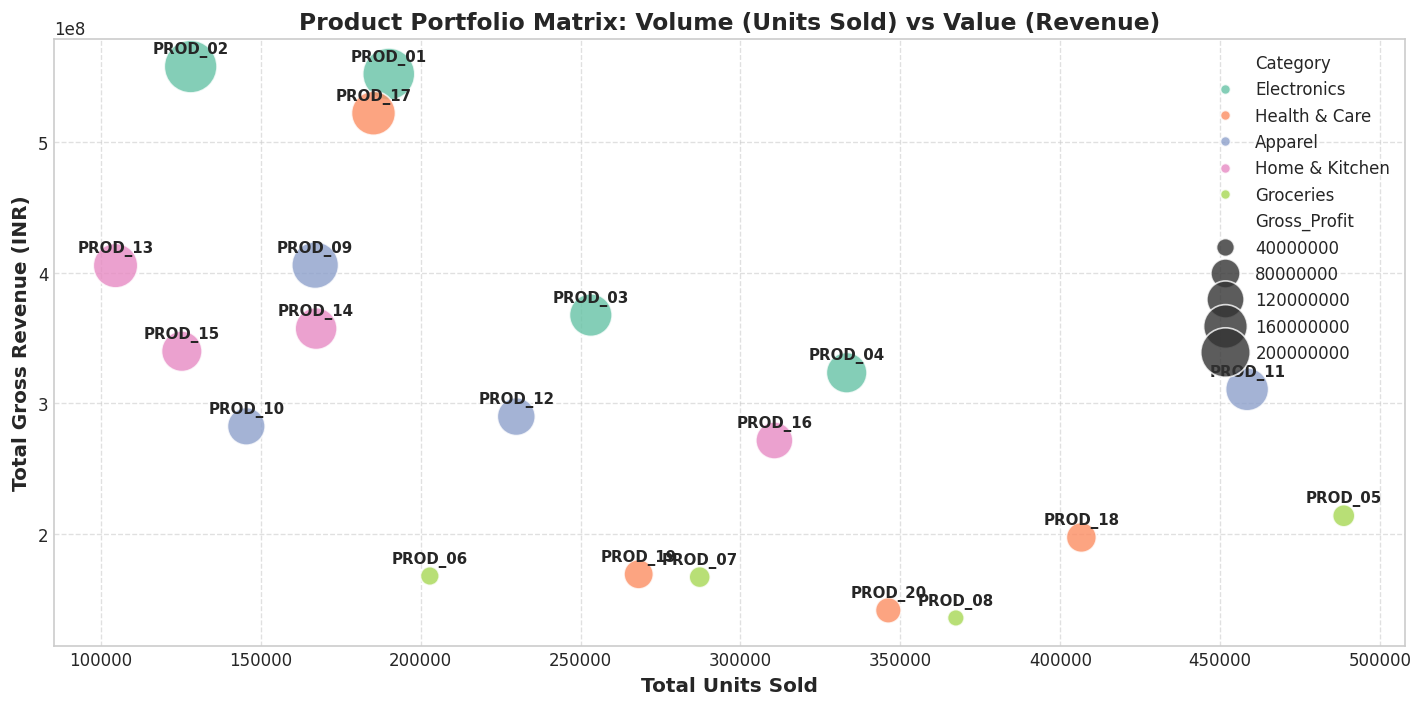

In [8]:
# Product Value vs Volume Matrix
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=prod_summary,
    x='Units_Sold',
    y='Revenue',
    size='Gross_Profit',
    hue='Category',
    sizes=(100, 1000),
    alpha=0.8,
    palette='Set2'
)

for _, row in prod_summary.iterrows():
    plt.annotate(
        row['Product_ID'],
        (row['Units_Sold'], row['Revenue']),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Product Portfolio Matrix: Volume (Units Sold) vs Value (Revenue)', fontsize=14, fontweight='bold')
plt.xlabel('Total Units Sold', fontsize=12, fontweight='bold')
plt.ylabel('Total Gross Revenue (INR)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## 5. Category Performance
Revenue contributions, unit volume distribution, and gross margin health across merchandise categories.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12592\1503297651.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_summary, x='Category', y='Gross_Margin_%', ax=axes[1], palette='crest')


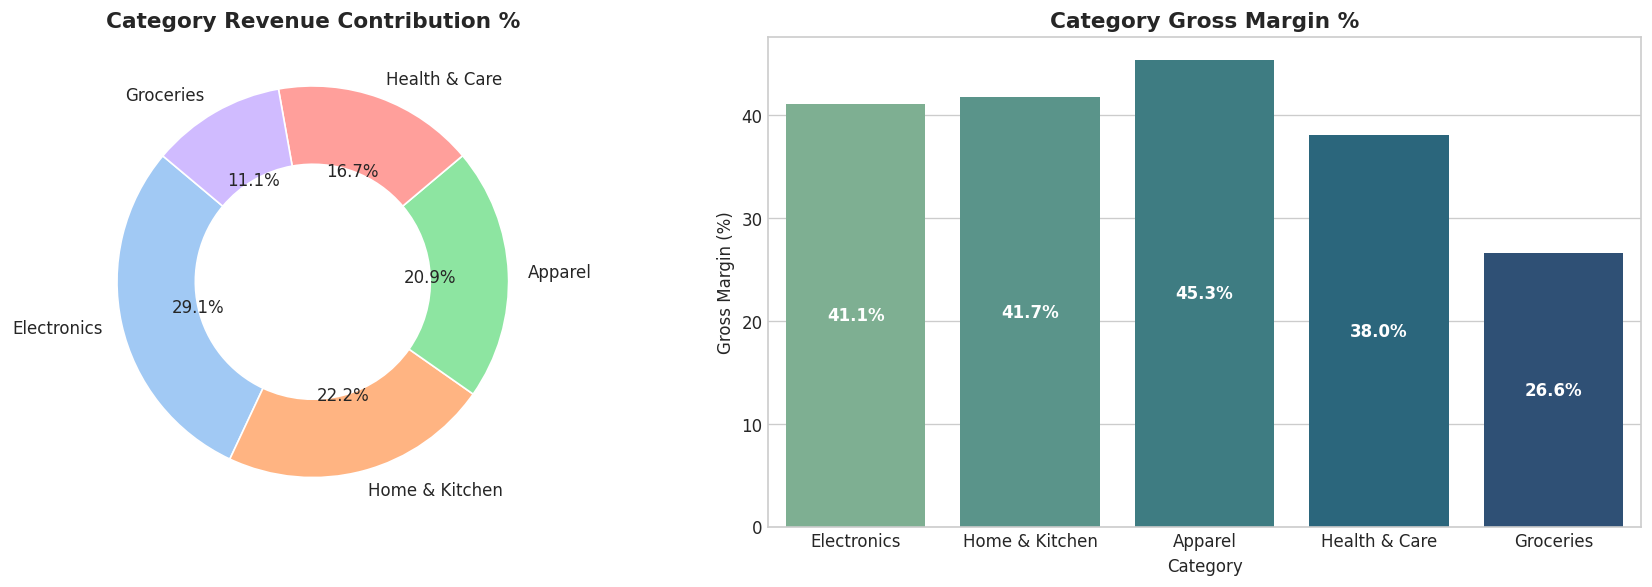

In [9]:
cat_summary = df.groupby('Category').agg({
    'Revenue': 'sum',
    'Units_Sold': 'sum',
    'Gross_Profit': 'sum',
    'Our_Price': 'mean',
    'Competitor_Price': 'mean'
}).reset_index().sort_values(by='Revenue', ascending=False)

cat_summary['Revenue_Share_%'] = (cat_summary['Revenue'] / total_revenue) * 100.0
cat_summary['Gross_Margin_%'] = (cat_summary['Gross_Profit'] / cat_summary['Revenue']) * 100.0
cat_summary['Price_Gap_%'] = ((cat_summary['Our_Price'] - cat_summary['Competitor_Price']) / cat_summary['Competitor_Price']) * 100.0

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Donut Chart for Revenue Share
axes[0].pie(cat_summary['Revenue_Share_%'], labels=cat_summary['Category'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'), wedgeprops=dict(width=0.4, edgecolor='w'))
axes[0].set_title('Category Revenue Contribution %', fontsize=13, fontweight='bold')

# Margin vs Price Gap
sns.barplot(data=cat_summary, x='Category', y='Gross_Margin_%', ax=axes[1], palette='crest')
axes[1].set_title('Category Gross Margin %', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Gross Margin (%)')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2., p.get_height()/2), ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()


## 6. Store & Regional Performance
Regional revenue distribution, pricing divergence, and store traffic benchmarks across North, South, West, and East metros.


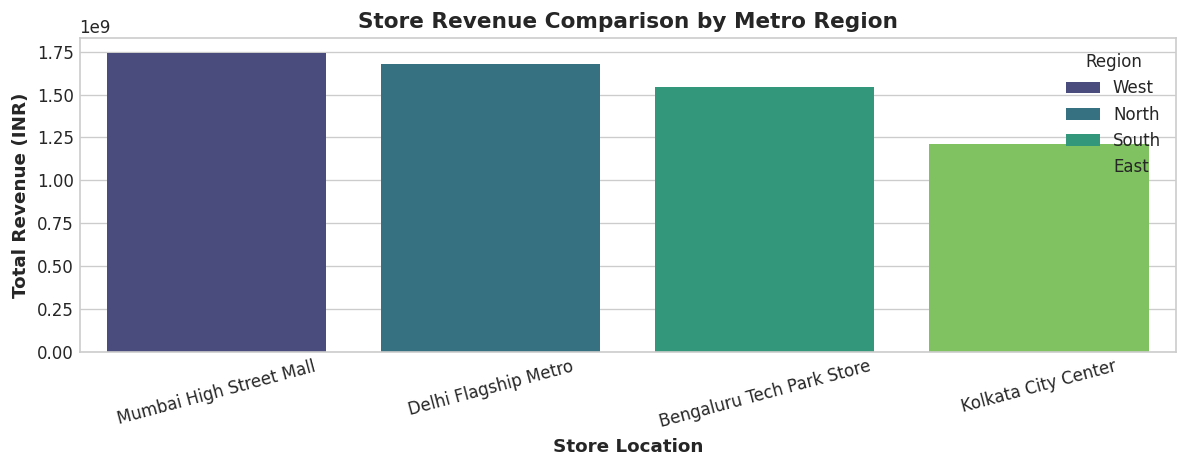

In [10]:
store_summary = df.groupby(['Store_ID', 'Store_Name', 'Region']).agg({
    'Revenue': 'sum',
    'Units_Sold': 'sum',
    'Gross_Profit': 'sum',
    'Our_Price': 'mean'
}).reset_index().sort_values(by='Revenue', ascending=False)

store_summary['Revenue_Contribution_%'] = (store_summary['Revenue'] / total_revenue) * 100.0

plt.figure(figsize=(10, 4))
sns.barplot(data=store_summary, x='Store_Name', y='Revenue', hue='Region', dodge=False, palette='viridis')
plt.title('Store Revenue Comparison by Metro Region', fontsize=13, fontweight='bold')
plt.xlabel('Store Location', fontsize=11, fontweight='bold')
plt.ylabel('Total Revenue (INR)', fontsize=11, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 7. Professional Pricing Analytics
Analyzing empirical Price vs Demand curves, Competitor Price interactions, Price Premium distribution, and Pricing Gap Segments.


In [11]:
# Define pricing segments
df['Price_Segment'] = np.where(
    df['Price_Premium_Percent'] < -2.0, 'Below Competitor (>2% cheaper)',
    np.where(df['Price_Premium_Percent'] > 2.0, 'Above Competitor (>2% expensive)', 'At Competitor (Within +/-2%)')
)

segment_summary = df.groupby('Price_Segment').agg({
    'Revenue': 'sum',
    'Units_Sold': 'sum',
    'Product_ID': 'count'
}).reset_index().rename(columns={'Product_ID': 'Observation_Count'})

segment_summary['Revenue_Share_%'] = (segment_summary['Revenue'] / total_revenue) * 100.0

print("Pricing Position Segmentation:")
print(tabulate(segment_summary, headers='keys', tablefmt='psql', floatfmt=('.2f', ',.2f', ',.2f', ',.2f', '.2f')))


Pricing Position Segmentation:
+----+----------------------------------+------------------+--------------+---------------------+-------------------+
|    | Price_Segment                    |          Revenue |   Units_Sold |   Observation_Count |   Revenue_Share_% |
|----+----------------------------------+------------------+--------------+---------------------+-------------------|
|  0 | Above Competitor (>2% expensive) | 1,701,766,957.02 |      1407536 |               17446 |           27.5484 |
|  1 | At Competitor (Within +/-2%)     | 1,324,331,275.78 |      1101753 |               13125 |           21.4384 |
|  2 | Below Competitor (>2% cheaper)   | 3,151,268,369.18 |      2656269 |               27909 |           51.0131 |
+----+----------------------------------+------------------+--------------+---------------------+-------------------+


C:\Users\LENOVO\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
C:\Users\LENOVO\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


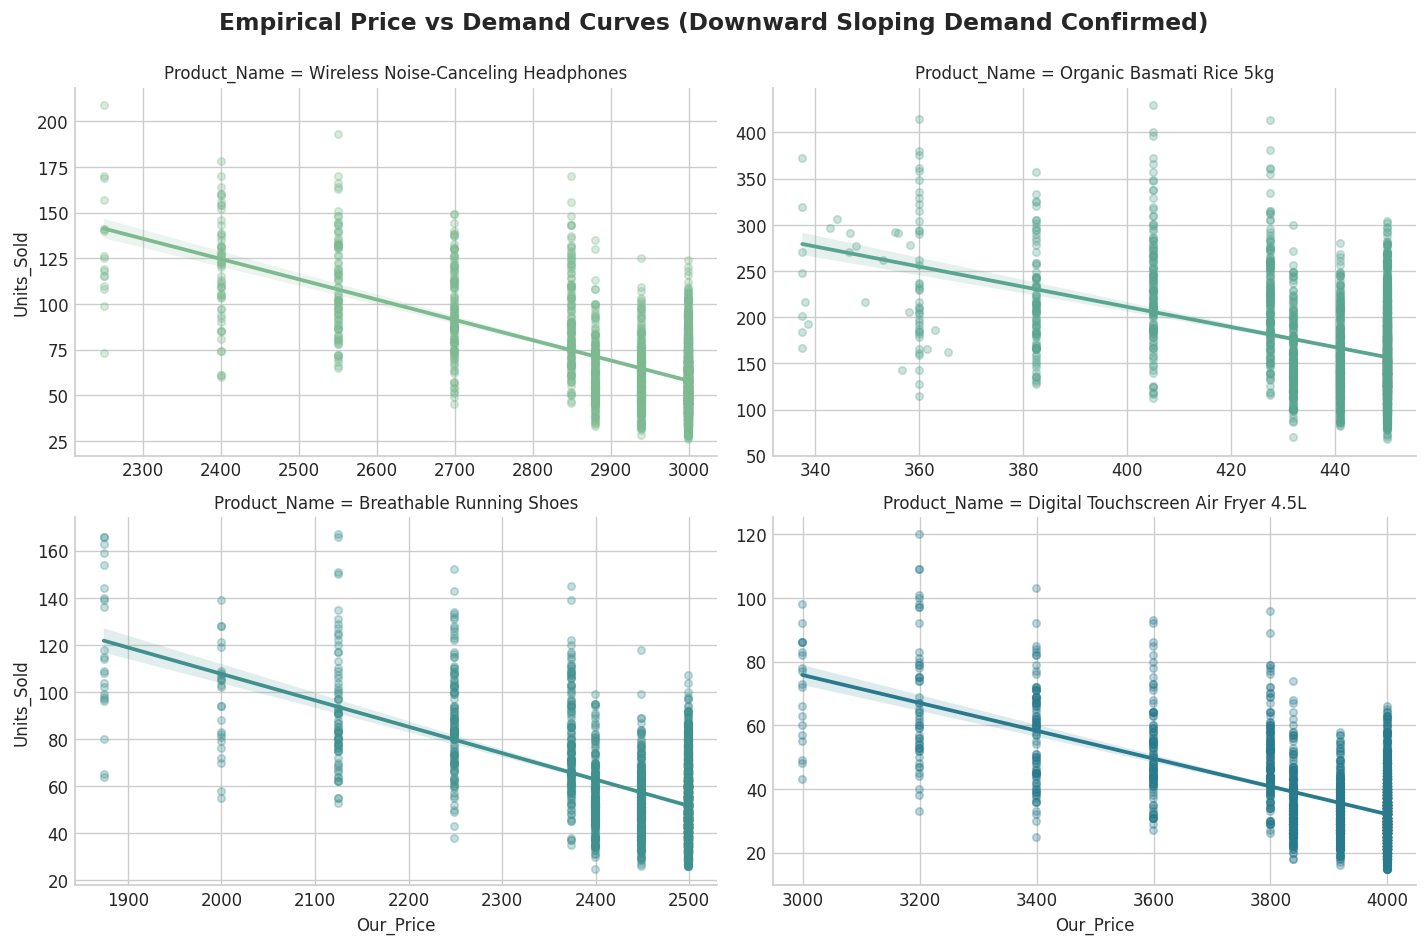

In [12]:
# Price vs Demand Scatter with Trendlines for Representative Products
sample_products = ['PROD_01', 'PROD_05', 'PROD_09', 'PROD_13']
sample_df = df[df['Product_ID'].isin(sample_products)]

g = sns.lmplot(
    data=sample_df,
    x='Our_Price',
    y='Units_Sold',
    hue='Product_Name',
    col='Product_Name',
    col_wrap=2,
    height=4,
    aspect=1.5,
    scatter_kws={'alpha': 0.3, 's': 20},
    sharex=False,
    sharey=False
)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Empirical Price vs Demand Curves (Downward Sloping Demand Confirmed)', fontsize=14, fontweight='bold')
plt.show()


## 8. Automated Business Insights & Decision Support
Dynamic generation of analytical takeaways directly derived from empirical calculations.


In [13]:
top_cat = cat_summary.iloc[0]
top_prod = prod_summary.iloc[0]
top_store = store_summary.iloc[0]

print("=== EXECUTIVE BUSINESS & PRICING INSIGHTS ===")
print(f"1. Top Category: '{top_cat['Category']}' leads revenue at INR {top_cat['Revenue']:,.2f} ({top_cat['Revenue_Share_%']:.1f}% share) with a {top_cat['Gross_Margin_%']:.1f}% margin.")
print(f"2. Star Product: '{top_prod['Product_Name']}' ({top_prod['Product_ID']}) generates INR {top_prod['Revenue']:,.2f} ({top_prod['Revenue_Share_%']:.1f}% of total enterprise revenue).")
print(f"3. Leading Location: '{top_store['Store_Name']}' ({top_store['Region']} Region) drives INR {top_store['Revenue']:,.2f} ({top_store['Revenue_Contribution_%']:.1f}% share).")
print(f"4. Pricing Stance: Average enterprise price is {avg_price_gap:+.2f}% relative to competitors, indicating an active opportunity for strategic price capture in inelastic categories.")
print(f"5. Dynamic Pricing Suitability: Verified downward sloping demand across all 20 product categories with mean correlation of {audit['mean_price_demand_correlation']:.2f}.")


=== EXECUTIVE BUSINESS & PRICING INSIGHTS ===
1. Top Category: 'Electronics' leads revenue at INR 1,800,391,051.22 (29.1% share) with a 41.1% margin.
2. Star Product: 'Smart Fitness Watch' (PROD_02) generates INR 557,648,665.53 (9.0% of total enterprise revenue).
3. Leading Location: 'Mumbai High Street Mall' (West Region) drives INR 1,742,957,618.68 (28.2% share).
4. Pricing Stance: Average enterprise price is -2.06% relative to competitors, indicating an active opportunity for strategic price capture in inelastic categories.
5. Dynamic Pricing Suitability: Verified downward sloping demand across all 20 product categories with mean correlation of -0.56.
